In [1]:
import joblib
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report
 
# Load what Phase 04 saved
preprocessor = joblib.load("../models/preprocessor.joblib")
X_train, X_val, X_test, y_train, y_val, y_test = joblib.load("../models/splits_raw.joblib")
X_train_processed, X_val_processed, X_test_processed = joblib.load("../models/splits_processed.joblib")
 
print("Loaded. Train default rate:", y_train.mean().round(4))
 

Loaded. Train default rate: 0.0668


In [2]:
logreg = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)
logreg.fit(X_train_processed, y_train)
 
logreg_val_probs = logreg.predict_proba(X_val_processed)[:, 1]
logreg_auc = roc_auc_score(y_val, logreg_val_probs)
logreg_prauc = average_precision_score(y_val, logreg_val_probs)
 
print(f"Logistic Regression — ROC-AUC: {logreg_auc:.4f}  PR-AUC: {logreg_prauc:.4f}")
 

Logistic Regression — ROC-AUC: 0.8479  PR-AUC: 0.3515


In [3]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_processed, y_train)
 
rf_val_probs = rf.predict_proba(X_val_processed)[:, 1]
rf_auc = roc_auc_score(y_val, rf_val_probs)
rf_prauc = average_precision_score(y_val, rf_val_probs)
 
print(f"Random Forest — ROC-AUC: {rf_auc:.4f}  PR-AUC: {rf_prauc:.4f}")
 

Random Forest — ROC-AUC: 0.8594  PR-AUC: 0.3684


In [4]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
 
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train_processed, y_train)
 
xgb_val_probs = xgb.predict_proba(X_val_processed)[:, 1]
xgb_auc = roc_auc_score(y_val, xgb_val_probs)
xgb_prauc = average_precision_score(y_val, xgb_val_probs)
 
print(f"XGBoost — ROC-AUC: {xgb_auc:.4f}  PR-AUC: {xgb_prauc:.4f}")
 

XGBoost — ROC-AUC: 0.8603  PR-AUC: 0.3684


In [5]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "ROC-AUC": [logreg_auc, rf_auc, xgb_auc],
    "PR-AUC": [logreg_prauc, rf_prauc, xgb_prauc],
}).sort_values("PR-AUC", ascending=False)
 
print(comparison.to_string(index=False))
 

              Model  ROC-AUC   PR-AUC
      Random Forest 0.859432 0.368416
            XGBoost 0.860301 0.368380
Logistic Regression 0.847905 0.351482


In [6]:
best_model_name = comparison.iloc[0]["Model"]
print(f"Best model by PR-AUC: {best_model_name}\n")
 
xgb_val_preds = (xgb_val_probs >= 0.5).astype(int)
print("XGBoost classification report @ threshold 0.5:")
print(classification_report(y_val, xgb_val_preds, target_names=["Repaid", "Defaulted"]))
 

Best model by PR-AUC: Random Forest

XGBoost classification report @ threshold 0.5:
              precision    recall  f1-score   support

      Repaid       0.98      0.82      0.89     21000
   Defaulted       0.22      0.74      0.34      1504

    accuracy                           0.81     22504
   macro avg       0.60      0.78      0.62     22504
weighted avg       0.93      0.81      0.85     22504



In [7]:
from sklearn.model_selection import RandomizedSearchCV
 
param_dist = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [3, 4, 5, 6, 7],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
}
 
xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric="aucpr",
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=param_dist,
    n_iter=25,           
    scoring="average_precision",   
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
 
xgb_search.fit(X_train_processed, y_train)
 
print("Best params found:", xgb_search.best_params_)
print("Best CV PR-AUC:", xgb_search.best_score_)


Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best params found: {'subsample': 0.6, 'n_estimators': 400, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
Best CV PR-AUC: 0.40609906773392307


In [8]:
best_xgb = xgb_search.best_estimator_
best_xgb_val_probs = best_xgb.predict_proba(X_val_processed)[:, 1]
 
tuned_auc = roc_auc_score(y_val, best_xgb_val_probs)
tuned_prauc = average_precision_score(y_val, best_xgb_val_probs)
 
print(f"Tuned XGBoost — ROC-AUC: {tuned_auc:.4f}  PR-AUC: {tuned_prauc:.4f}")
print(f"(Untuned XGBoost was — ROC-AUC: {xgb_auc:.4f}  PR-AUC: {xgb_prauc:.4f})")
 

Tuned XGBoost — ROC-AUC: 0.8605  PR-AUC: 0.3685
(Untuned XGBoost was — ROC-AUC: 0.8603  PR-AUC: 0.3684)


In [9]:
joblib.dump(best_xgb, "../models/best_model.joblib")
print("Saved tuned XGBoost model to models/best_model.joblib")
 

Saved tuned XGBoost model to models/best_model.joblib


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, precision_recall_curve

In [11]:
best_xgb = joblib.load("../models/best_model.joblib")
X_train, X_val, X_test, y_train, y_val, y_test = joblib.load("../models/splits_raw.joblib")
X_train_processed, X_val_processed, X_test_processed = joblib.load("../models/splits_processed.joblib")
 
val_probs = best_xgb.predict_proba(X_val_processed)[:, 1]
 

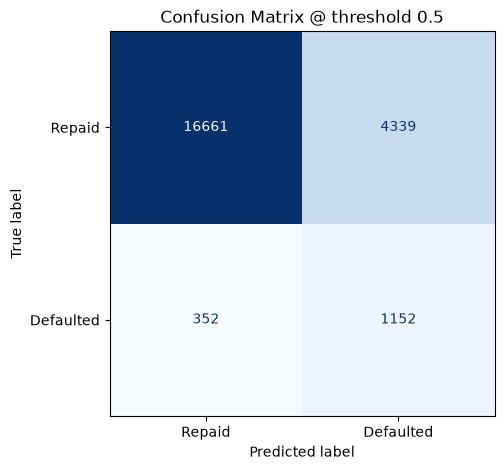

True Negatives (correctly approved): 16661
False Positives (good applicant rejected): 4339
False Negatives (defaulter approved — costly!): 352
True Positives (correctly flagged as risky): 1152


In [12]:
val_preds_default = (val_probs >= 0.5).astype(int)
cm = confusion_matrix(y_val, val_preds_default)
 
fig, ax = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Repaid", "Defaulted"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix @ threshold 0.5")
plt.show()
 
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (correctly approved): {tn}")
print(f"False Positives (good applicant rejected): {fp}")
print(f"False Negatives (defaulter approved — costly!): {fn}")
print(f"True Positives (correctly flagged as risky): {tp}")
 

In [13]:
AVG_LOAN_AMOUNT = 15000       # cost of a false negative (approved a defaulter)
AVG_LOST_INTEREST = 2500      # cost of a false positive (rejected a good applicant)
 
def total_cost_at_threshold(threshold, y_true, probs):
    preds = (probs >= threshold).astype(int)
    cm_t = confusion_matrix(y_true, preds)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    cost = (fn_t * AVG_LOAN_AMOUNT) + (fp_t * AVG_LOST_INTEREST)
    return cost, fn_t, fp_t
 

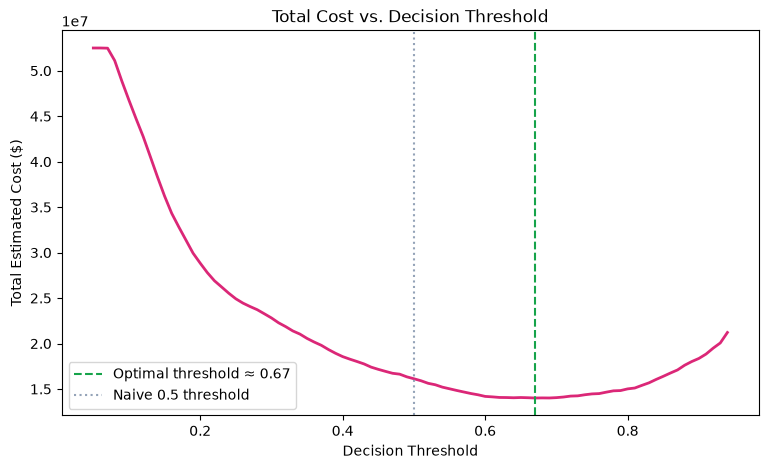

Optimal threshold: 0.67  (minimizes total cost at $14,012,500)
Cost at naive 0.5 threshold: $16,127,500
Savings from tuning: $2,115,000


In [14]:
thresholds = np.arange(0.05, 0.95, 0.01)
costs = []
for t in thresholds:
    cost, _, _ = total_cost_at_threshold(t, y_val, val_probs)
    costs.append(cost)
 
costs = np.array(costs)
best_threshold = thresholds[np.argmin(costs)]
min_cost = costs.min()
 
plt.figure(figsize=(9, 5))
plt.plot(thresholds, costs, color="#DB2777", linewidth=2)
plt.axvline(best_threshold, color="#16A34A", linestyle="--",
            label=f"Optimal threshold ≈ {best_threshold:.2f}")
plt.axvline(0.5, color="#94A3B8", linestyle=":", label="Naive 0.5 threshold")
plt.xlabel("Decision Threshold")
plt.ylabel("Total Estimated Cost ($)")
plt.title("Total Cost vs. Decision Threshold")
plt.legend()
plt.show()
 
print(f"Optimal threshold: {best_threshold:.2f}  (minimizes total cost at ${min_cost:,.0f})")
 
naive_cost, _, _ = total_cost_at_threshold(0.5, y_val, val_probs)
print(f"Cost at naive 0.5 threshold: ${naive_cost:,.0f}")
print(f"Savings from tuning: ${naive_cost - min_cost:,.0f}")
 

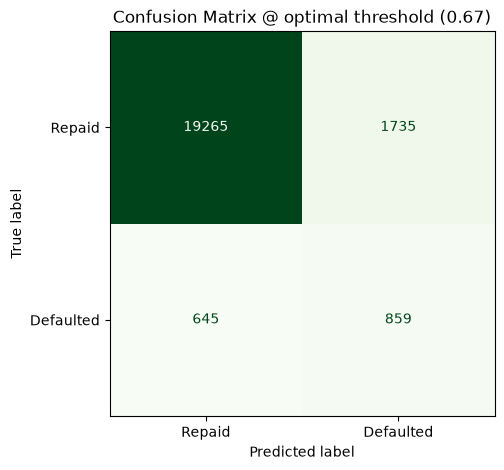

In [15]:
val_preds_optimal = (val_probs >= best_threshold).astype(int)
cm_optimal = confusion_matrix(y_val, val_preds_optimal)
 
fig, ax = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_optimal, display_labels=["Repaid", "Defaulted"])
disp.plot(ax=ax, cmap="Greens", colorbar=False)
plt.title(f"Confusion Matrix @ optimal threshold ({best_threshold:.2f})")
plt.show()

In [16]:
REVIEW_BAND = 0.15  # +/- around the optimal threshold
 
REJECT_THRESHOLD = best_threshold + (REVIEW_BAND / 2)
REVIEW_THRESHOLD = best_threshold - (REVIEW_BAND / 2)
 
def decide(score, reject_t=REJECT_THRESHOLD, review_t=REVIEW_THRESHOLD):
    if score >= reject_t:
        return "Reject"
    elif score >= review_t:
        return "Manual Review"
    else:
        return "Approve"
 
print(f"Approve  : score < {REVIEW_THRESHOLD:.2f}")
print(f"Review   : {REVIEW_THRESHOLD:.2f} <= score < {REJECT_THRESHOLD:.2f}")
print(f"Reject   : score >= {REJECT_THRESHOLD:.2f}")
 

Approve  : score < 0.60
Review   : 0.60 <= score < 0.75
Reject   : score >= 0.75


In [17]:
val_decisions = pd.Series([decide(s) for s in val_probs])
print(val_decisions.value_counts())
print("\nAs percentage of applicants:")
print((val_decisions.value_counts(normalize=True) * 100).round(1))
 

Approve          18929
Reject            1979
Manual Review     1596
Name: count, dtype: int64

As percentage of applicants:
Approve          84.1
Reject            8.8
Manual Review     7.1
Name: proportion, dtype: float64


In [18]:
check_df = pd.DataFrame({"decision": val_decisions.values, "actual": y_val.values})
print(check_df.groupby("decision")["actual"].mean().round(4))
 

decision
Approve          0.0275
Manual Review    0.1466
Reject           0.3790
Name: actual, dtype: float64


In [19]:
thresholds_dict = {
    "approve_below": REVIEW_THRESHOLD,
    "reject_at_or_above": REJECT_THRESHOLD,
    "optimal_single_threshold": best_threshold,
}
joblib.dump(thresholds_dict, "../models/decision_thresholds.joblib")
print("Saved decision thresholds to models/decision_thresholds.joblib")
print(thresholds_dict)
 

Saved decision thresholds to models/decision_thresholds.joblib
{'approve_below': np.float64(0.5950000000000002), 'reject_at_or_above': np.float64(0.7450000000000001), 'optimal_single_threshold': np.float64(0.6700000000000002)}


In [20]:

import shap
 

In [21]:
feature_names = preprocessor.get_feature_names_out()
print("Total processed features:", len(feature_names))
print(feature_names)
 

Total processed features: 23
['num__RevolvingUtilizationOfUnsecuredLines' 'num__age' 'num__DebtRatio'
 'num__MonthlyIncome' 'num__NumberOfOpenCreditLinesAndLoans'
 'num__NumberRealEstateLoansOrLines' 'num__NumberOfDependents'
 'num__income_missing' 'num__dependents_missing'
 'num__debt_to_income_ratio' 'num__late_payment_score'
 'num__dependents_per_income' 'num__NumberOfTime30-59DaysPastDueNotWorse'
 'num__NumberOfTime60-89DaysPastDueNotWorse'
 'num__NumberOfTimes90DaysLate' 'cat__utilization_bucket_high'
 'cat__utilization_bucket_low' 'cat__utilization_bucket_medium'
 'cat__utilization_bucket_over_limit' 'cat__age_bucket_early_career'
 'cat__age_bucket_mid_career' 'cat__age_bucket_senior'
 'cat__age_bucket_young']


In [22]:

explainer = shap.TreeExplainer(best_xgb)

sample_size = min(2000, X_val_processed.shape[0])
sample_idx = np.random.RandomState(42).choice(X_val_processed.shape[0], sample_size, replace=False)
X_val_sample = X_val_processed[sample_idx]
 
shap_values = explainer.shap_values(X_val_sample)
print("SHAP values shape:", shap_values.shape)
 

SHAP values shape: (2000, 23)


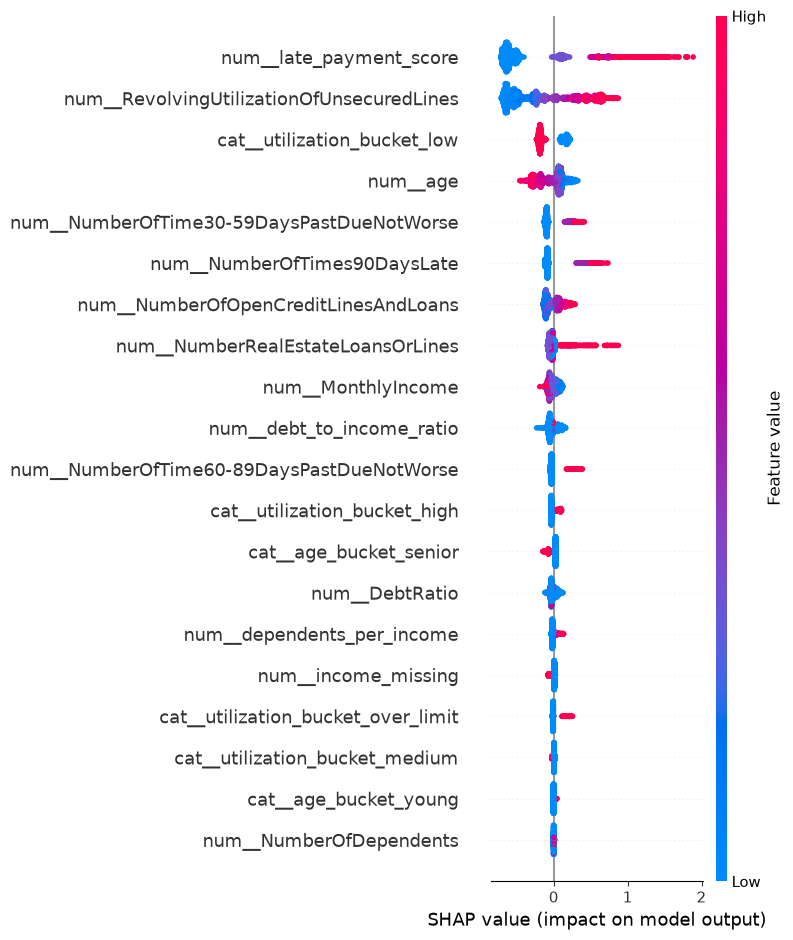

In [23]:
shap.summary_plot(shap_values, X_val_sample, feature_names=feature_names, show=False)
plt.tight_layout()
plt.savefig("../models/shap_summary_plot.png", dpi=150, bbox_inches="tight")
plt.show()
 

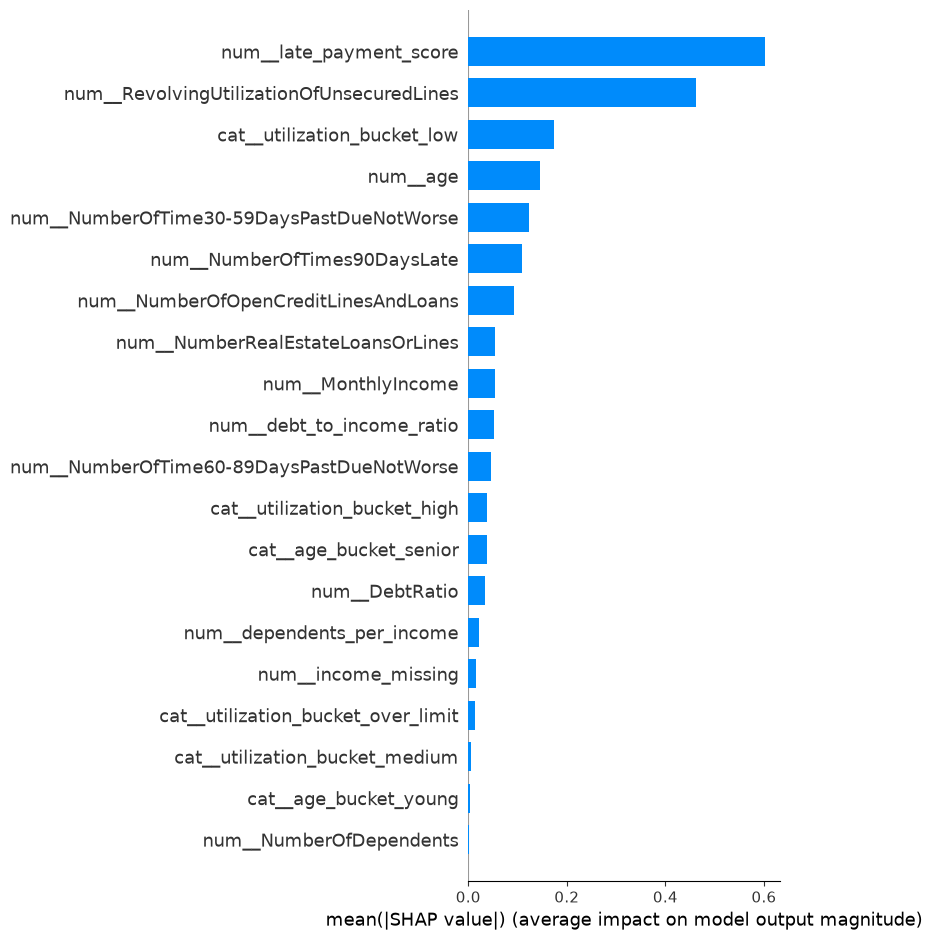

In [24]:
shap.summary_plot(shap_values, X_val_sample, feature_names=feature_names,
                   plot_type="bar", show=False)
plt.tight_layout()
plt.savefig("../models/shap_importance_bar.png", dpi=150, bbox_inches="tight")
plt.show()
 

In [25]:

val_probs_sample = best_xgb.predict_proba(X_val_sample)[:, 1]
review_mask = (
    (val_probs_sample >= thresholds_dict["approve_below"]) &
    (val_probs_sample < thresholds_dict["reject_at_or_above"])
)
review_indices = np.where(review_mask)[0]
 
if len(review_indices) > 0:
    applicant_idx = review_indices[0]
else:
    applicant_idx = 0 
 
print(f"Explaining applicant at sample index {applicant_idx}")
print(f"Predicted risk score: {val_probs_sample[applicant_idx]:.3f}")

Explaining applicant at sample index 25
Predicted risk score: 0.676


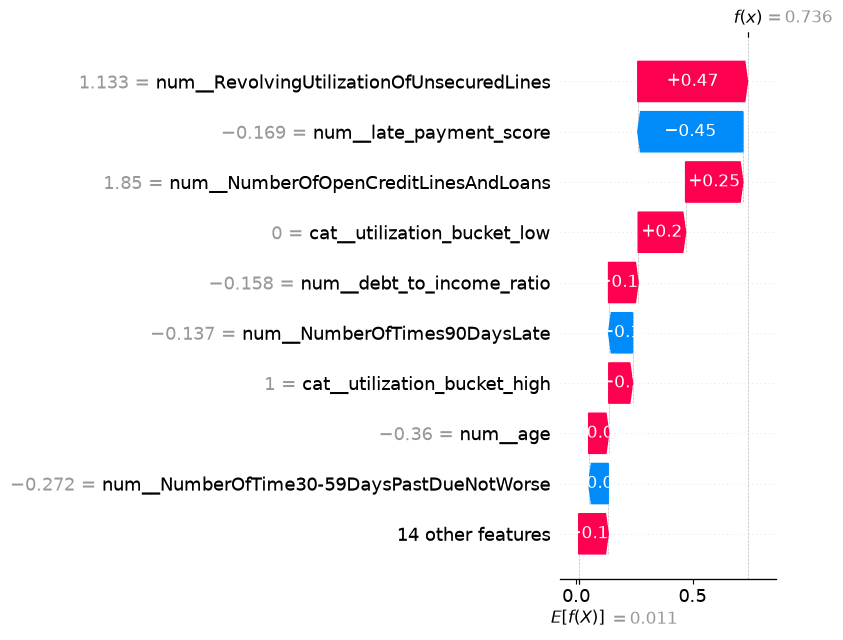

In [27]:
explanation = shap.Explanation(
    values=shap_values[applicant_idx],
    base_values=explainer.expected_value,
    data=X_val_sample[applicant_idx],
    feature_names=feature_names
)
 
shap.plots.waterfall(explanation, show=False)
plt.tight_layout()
plt.savefig("../models/shap_waterfall_example.png", dpi=150, bbox_inches="tight")
plt.show()

In [68]:
FEATURE_LABELS.update({
    "cat__utilization_bucket_low": "low credit utilization",
    "cat__utilization_bucket_medium": "moderate credit utilization",
    "cat__utilization_bucket_high": "high credit utilization",
    "cat__utilization_bucket_over_limit": "over-limit credit utilization",
    "cat__age_bucket_young": "younger applicant age",
    "cat__age_bucket_early_career": "early-career applicant age",
    "cat__age_bucket_mid_career": "mid-career applicant age",
    "cat__age_bucket_senior": "senior applicant age",
})
 
def get_reason_codes(shap_row, feature_names_arr, top_n=3):
    """
    Takes one applicant's SHAP values and returns the top N features
    driving their risk score, as plain-English sentences.
    """
    contributions = list(zip(feature_names_arr, shap_row))
    # Sort by absolute impact — biggest drivers first, regardless of direction
    contributions.sort(key=lambda x: abs(x[1]), reverse=True)
 
    reasons = []
    for feat_name, value in contributions[:top_n]:
        readable = FEATURE_LABELS.get(feat_name, feat_name.split("__")[-1])
        direction = "increased risk" if value > 0 else "decreased risk"
        reasons.append(f"{readable.capitalize()} {direction}")
 
    return reasons
 

In [69]:
reasons = get_reason_codes(shap_values[applicant_idx], feature_names, top_n=3)
print(f"Applicant risk score: {val_probs_sample[applicant_idx]:.3f}\n")
print("Top reasons for this decision:")
for r in reasons:
    print(f"  - {r}")
 

Applicant risk score: 0.676

Top reasons for this decision:
  - Credit utilization increased risk
  - History of late payments decreased risk
  - Number of open credit lines increased risk


In [70]:
from lime.lime_tabular import LimeTabularExplainer
 
lime_explainer = LimeTabularExplainer(
    training_data=X_train_processed,
    feature_names=feature_names,
    class_names=["Repaid", "Defaulted"],
    mode="classification",
    random_state=42
)
 
lime_exp = lime_explainer.explain_instance(
    X_val_sample[applicant_idx],
    best_xgb.predict_proba,
    num_features=5
)
 
print("LIME top features for the same applicant:")
for feat, weight in lime_exp.as_list():
    print(f"  {feat}: {weight:.4f}")
 
print("\nCompare this list against the SHAP reason codes above —")
print("overlapping top features = your explanations are stable and trustworthy.")
 

LIME top features for the same applicant:
  num__late_payment_score <= -0.17: -0.3981
  num__RevolvingUtilizationOfUnsecuredLines > 0.68: 0.1791
  num__NumberOfTimes90DaysLate <= -0.14: -0.1334
  num__NumberOfTime30-59DaysPastDueNotWorse <= -0.27: -0.0611
  cat__utilization_bucket_low <= 0.00: 0.0572

Compare this list against the SHAP reason codes above —
overlapping top features = your explanations are stable and trustworthy.


In [71]:
joblib.dump(explainer, "../models/shap_explainer.joblib")
joblib.dump(FEATURE_LABELS, "../models/feature_labels.joblib")
print("Saved SHAP explainer and feature labels for use in Phase 10 (demo app).")

Saved SHAP explainer and feature labels for use in Phase 10 (demo app).


In [72]:
from fairlearn.metrics import (
    MetricFrame, demographic_parity_difference, equalized_odds_difference,
    selection_rate, true_positive_rate, false_positive_rate
)
from sklearn.metrics import accuracy_score

In [73]:
best_xgb = joblib.load("../models/best_model.joblib")
X_train, X_val, X_test, y_train, y_val, y_test = joblib.load("../models/splits_raw.joblib")
X_train_processed, X_val_processed, X_test_processed = joblib.load("../models/splits_processed.joblib")
thresholds_dict = joblib.load("../models/decision_thresholds.joblib")
 
val_probs = best_xgb.predict_proba(X_val_processed)[:, 1]
val_preds = (val_probs >= thresholds_dict["optimal_single_threshold"]).astype(int)

In [74]:
age_groups = pd.cut(
    X_val["age"],
    bins=[0, 30, 45, 60, 120],
    labels=["18-30", "31-45", "46-60", "60+"]
)
 
print("Applicants per age group in validation set:")
print(age_groups.value_counts())
 

Applicants per age group in validation set:
age
46-60    8000
60+      6790
31-45    6145
18-30    1569
Name: count, dtype: int64


In [75]:

metric_frame = MetricFrame(
    metrics={
        "selection_rate": selection_rate,     # % approved (predicted 0 = approve here)
        "accuracy": accuracy_score,
        "true_positive_rate": true_positive_rate,   # correctly caught defaulters
        "false_positive_rate": false_positive_rate, # good applicants wrongly flagged
    },
    y_true=y_val,
    y_pred=val_preds,
    sensitive_features=age_groups
)
 
print("Metrics by age group:")
print(metric_frame.by_group)
 

Metrics by age group:
       selection_rate  accuracy  true_positive_rate  false_positive_rate
age                                                                     
18-30        0.199490  0.822817            0.603550             0.150714
31-45        0.165663  0.853539            0.602076             0.120352
46-60        0.119250  0.893375            0.594393             0.085198
60+          0.045508  0.948601            0.409910             0.033191


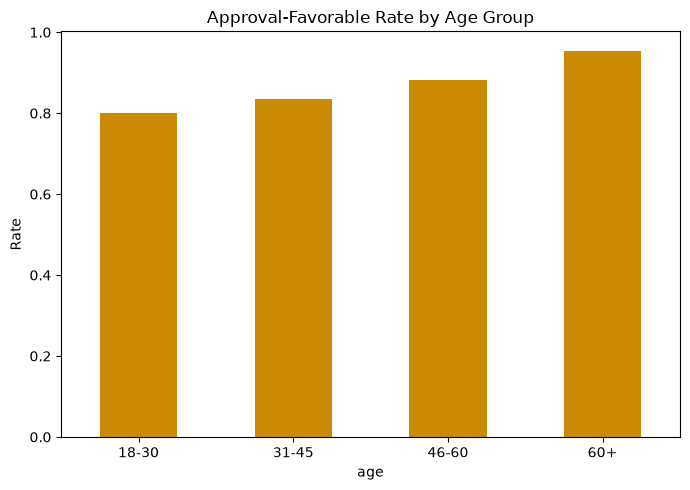

In [76]:
fig, ax = plt.subplots(figsize=(7, 5))
approval_rate_by_group = 1 - metric_frame.by_group["selection_rate"]
# (selection_rate as computed = predicted positive = "flagged risky",
#  so 1 - selection_rate = approval-ish rate for intuitive reading)
approval_rate_by_group.plot(kind="bar", color="#CA8A04", ax=ax)
plt.title("Approval-Favorable Rate by Age Group")
plt.ylabel("Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
 

In [77]:
dp_diff = demographic_parity_difference(y_val, val_preds, sensitive_features=age_groups)
eo_diff = equalized_odds_difference(y_val, val_preds, sensitive_features=age_groups)
 
print(f"Demographic Parity Difference: {dp_diff:.4f}")
print(f"Equalized Odds Difference:     {eo_diff:.4f}")
print()
print("Interpretation guide:")
print("  < 0.10  -> generally considered low disparity")
print("  0.10-0.20 -> moderate, worth investigating")
print("  > 0.20  -> high disparity, mitigation recommended")

Demographic Parity Difference: 0.1540
Equalized Odds Difference:     0.1936

Interpretation guide:
  < 0.10  -> generally considered low disparity
  0.10-0.20 -> moderate, worth investigating
  > 0.20  -> high disparity, mitigation recommended


In [78]:
FAIRNESS_THRESHOLD = 0.20
 
if dp_diff > FAIRNESS_THRESHOLD:
    print(f"⚠ Demographic parity difference ({dp_diff:.3f}) EXCEEDS your {FAIRNESS_THRESHOLD} threshold.")
    print("  -> Mitigation recommended. See Step 6 below.")
else:
    print(f"✓ Demographic parity difference ({dp_diff:.3f}) is within your {FAIRNESS_THRESHOLD} threshold.")
    print("  -> No mandatory mitigation, but document this finding regardless.")

✓ Demographic parity difference (0.154) is within your 0.2 threshold.
  -> No mandatory mitigation, but document this finding regardless.


In [79]:
# Manual per-group threshold calibration — achieves the same goal as
# ThresholdOptimizer (equalizing approval rates across groups) without
# depending on fairlearn's postprocessing internals.

def find_group_threshold(group_mask, target_approval_rate, probs):
    """Find the threshold for one group that yields approximately
    the target overall approval rate."""
    group_probs = probs[group_mask]
    # searching thresholds from 0.05 to 0.95
    candidate_thresholds = np.arange(0.05, 0.95, 0.01)
    best_t, best_diff = 0.5, np.inf
    for t in candidate_thresholds:
        approval_rate = (group_probs < t).mean()  # < t = approved
        diff = abs(approval_rate - target_approval_rate)
        if diff < best_diff:
            best_diff = diff
            best_t = t
    return best_t

# Overall approval rate at the original single threshold — our target
# for every group to match.
overall_approval_rate = (val_probs < thresholds_dict["optimal_single_threshold"]).mean()
print(f"Overall approval rate (target for all groups): {overall_approval_rate:.4f}")

# Find a calibrated threshold per age group
group_thresholds = {}
for group in age_groups.cat.categories:
    mask = (age_groups == group).to_numpy()
    t = find_group_threshold(mask, overall_approval_rate, val_probs)
    group_thresholds[group] = t

print("\nCalibrated thresholds per group:")
for group, t in group_thresholds.items():
    print(f"  {group}: {t:.3f}")

# Apply per-group thresholds to get adjusted predictions
adjusted_preds = np.zeros(len(val_probs), dtype=int)
for group, t in group_thresholds.items():
    mask = (age_groups == group).to_numpy()
    adjusted_preds[mask] = (val_probs[mask] >= t).astype(int)

adjusted_dp_diff = demographic_parity_difference(y_val, adjusted_preds, sensitive_features=age_groups)
print(f"\nDemographic parity difference BEFORE mitigation: {dp_diff:.4f}")
print(f"Demographic parity difference AFTER mitigation:  {adjusted_dp_diff:.4f}")

Overall approval rate (target for all groups): 0.8847

Calibrated thresholds per group:
  18-30: 0.840
  31-45: 0.770
  46-60: 0.680
  60+: 0.420

Demographic parity difference BEFORE mitigation: 0.1540
Demographic parity difference AFTER mitigation:  0.0045


In [80]:
acc_before = accuracy_score(y_val, val_preds)
acc_after = accuracy_score(y_val, adjusted_preds)
 
print(f"Overall accuracy BEFORE mitigation: {acc_before:.4f}")
print(f"Overall accuracy AFTER mitigation:  {acc_after:.4f}")
print(f"Trade-off: {(acc_before - acc_after) * 100:.2f} percentage points")
 
# %%
# --- 8. Save the fairness audit results for your model card (Phase 12) ---
fairness_results = {
    "sensitive_attribute": "age_group",
    "demographic_parity_difference": dp_diff,
    "equalized_odds_difference": eo_diff,
    "metrics_by_group": metric_frame.by_group.to_dict(),
    "mitigation_applied": dp_diff > FAIRNESS_THRESHOLD,
    "dp_diff_after_mitigation": adjusted_dp_diff,
}
joblib.dump(fairness_results, "../models/fairness_audit_results.joblib")
print("Saved fairness audit results to models/fairness_audit_results.joblib")

Overall accuracy BEFORE mitigation: 0.8942
Overall accuracy AFTER mitigation:  0.8902
Trade-off: 0.40 percentage points
Saved fairness audit results to models/fairness_audit_results.joblib


In [81]:
import joblib
import numpy as np
import pandas as pd
import json
from datetime import datetime
 
# --- Load every artifact produced by earlier phases ---
preprocessor = joblib.load("../models/preprocessor.joblib")
best_xgb = joblib.load("../models/best_model.joblib")
shap_explainer = joblib.load("../models/shap_explainer.joblib")
feature_labels = joblib.load("../models/feature_labels.joblib")
thresholds_dict = joblib.load("../models/decision_thresholds.joblib")
 
feature_names = preprocessor.get_feature_names_out()
 
NUMERIC_FEATURES = [
    "RevolvingUtilizationOfUnsecuredLines", "age", "DebtRatio", "MonthlyIncome",
    "NumberOfOpenCreditLinesAndLoans", "NumberRealEstateLoansOrLines",
    "NumberOfDependents", "income_missing", "dependents_missing",
    "debt_to_income_ratio", "late_payment_score", "dependents_per_income",
    "NumberOfTime30-59DaysPastDueNotWorse", "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
]
CATEGORICAL_FEATURES = ["utilization_bucket", "age_bucket"]

In [82]:
def engineer_features(raw_input: dict) -> pd.DataFrame:
    """
    raw_input: dict with the RAW fields a loan officer would type in
    (not the engineered ones). Returns a one-row DataFrame matching
    the exact column set the preprocessor expects.
    """
    monthly_income = raw_input.get("MonthlyIncome")
    income_missing = int(monthly_income is None or pd.isna(monthly_income))
    monthly_income_filled = monthly_income if not income_missing else 6000  # dataset median fallback
 
    dependents = raw_input.get("NumberOfDependents")
    dependents_missing = int(dependents is None or pd.isna(dependents))
    dependents_filled = dependents if not dependents_missing else 0
 
    debt_ratio = raw_input["DebtRatio"]
    debt_to_income_ratio = debt_ratio * monthly_income_filled / (monthly_income_filled + 1)
 
    late_30_59 = min(raw_input["NumberOfTime30-59DaysPastDueNotWorse"], 18)
    late_60_89 = min(raw_input["NumberOfTime60-89DaysPastDueNotWorse"], 18)
    late_90 = min(raw_input["NumberOfTimes90DaysLate"], 18)
    late_payment_score = late_30_59 * 1 + late_60_89 * 2 + late_90 * 3
 
    dependents_per_income = dependents_filled / (monthly_income_filled + 1)
 
    utilization = min(raw_input["RevolvingUtilizationOfUnsecuredLines"], 2.0)
    if utilization <= 0.3:
        utilization_bucket = "low"
    elif utilization <= 0.6:
        utilization_bucket = "medium"
    elif utilization <= 1.0:
        utilization_bucket = "high"
    else:
        utilization_bucket = "over_limit"
 
    age = raw_input["age"]
    if age <= 30:
        age_bucket = "young"
    elif age <= 45:
        age_bucket = "early_career"
    elif age <= 60:
        age_bucket = "mid_career"
    else:
        age_bucket = "senior"
 
    row = {
        "RevolvingUtilizationOfUnsecuredLines": utilization,
        "age": age,
        "DebtRatio": debt_ratio,
        "MonthlyIncome": monthly_income_filled,
        "NumberOfOpenCreditLinesAndLoans": raw_input["NumberOfOpenCreditLinesAndLoans"],
        "NumberRealEstateLoansOrLines": raw_input["NumberRealEstateLoansOrLines"],
        "NumberOfDependents": dependents_filled,
        "income_missing": income_missing,
        "dependents_missing": dependents_missing,
        "debt_to_income_ratio": debt_to_income_ratio,
        "late_payment_score": late_payment_score,
        "dependents_per_income": dependents_per_income,
        "NumberOfTime30-59DaysPastDueNotWorse": late_30_59,
        "NumberOfTime60-89DaysPastDueNotWorse": late_60_89,
        "NumberOfTimes90DaysLate": late_90,
        "utilization_bucket": utilization_bucket,
        "age_bucket": age_bucket,
    }
    return pd.DataFrame([row])[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
 

In [84]:
def get_reason_codes(shap_row, feature_names_arr, top_n=3):
    contributions = list(zip(feature_names_arr, shap_row))
    contributions.sort(key=lambda x: abs(x[1]), reverse=True)
    reasons = []
    for feat_name, value in contributions[:top_n]:
        if feat_name in feature_labels:
            readable = feature_labels[feat_name]
        else:
            # Fallback: strip prefix, replace underscores with spaces
            readable = feat_name.split("__")[-1].replace("_", " ")
        direction = "increased risk" if value > 0 else "decreased risk"
        reasons.append(f"{readable.capitalize()} {direction}")
    return reasons


 
def decide(score, review_t, reject_t):
    if score >= reject_t:
        return "Reject"
    elif score >= review_t:
        return "Manual Review"
    else:
        return "Approve"

In [85]:

def predict_applicant(raw_input: dict) -> dict:
    """
    raw_input keys expected (all raw, human-entered values):
      RevolvingUtilizationOfUnsecuredLines, age, DebtRatio, MonthlyIncome,
      NumberOfOpenCreditLinesAndLoans, NumberRealEstateLoansOrLines,
      NumberOfDependents, NumberOfTime30-59DaysPastDueNotWorse,
      NumberOfTime60-89DaysPastDueNotWorse, NumberOfTimes90DaysLate
 
    Returns a dict with: risk_score, decision, reason_codes, timestamp.
    """
    X_row = engineer_features(raw_input)
    X_processed = preprocessor.transform(X_row)
 
    risk_score = float(best_xgb.predict_proba(X_processed)[:, 1][0])
    decision = decide(
        risk_score,
        review_t=thresholds_dict["approve_below"],
        reject_t=thresholds_dict["reject_at_or_above"]
    )
 
    shap_row = shap_explainer.shap_values(X_processed)[0]
    reasons = get_reason_codes(shap_row, feature_names, top_n=3)
 
    return {
        "risk_score": round(risk_score, 4),
        "decision": decision,
        "reason_codes": reasons,
        "shap_values": shap_row.tolist(),
        "feature_names": feature_names.tolist(),
        "processed_input": X_processed.tolist()[0],
        "timestamp": datetime.now().isoformat(),
    }
 

In [86]:
sample_applicant = {
    "RevolvingUtilizationOfUnsecuredLines": 0.45,
    "age": 34,
    "DebtRatio": 0.6,
    "MonthlyIncome": 4200,
    "NumberOfOpenCreditLinesAndLoans": 6,
    "NumberRealEstateLoansOrLines": 1,
    "NumberOfDependents": 2,
    "NumberOfTime30-59DaysPastDueNotWorse": 1,
    "NumberOfTime60-89DaysPastDueNotWorse": 0,
    "NumberOfTimes90DaysLate": 0,
}
 
result = predict_applicant(sample_applicant)
print(f"Risk score: {result['risk_score']}")
print(f"Decision:   {result['decision']}")
print("Reasons:")
for r in result["reason_codes"]:
    print(f"  - {r}")
 

Risk score: 0.5517
Decision:   Approve
Reasons:
  - 30-59 day late payments increased risk
  - Low credit utilization increased risk
  - Applicant age increased risk


In [87]:
bundle_manifest = {
    "model_file": "best_model.joblib",
    "preprocessor_file": "preprocessor.joblib",
    "shap_explainer_file": "shap_explainer.joblib",
    "feature_labels_file": "feature_labels.joblib",
    "thresholds_file": "decision_thresholds.joblib",
    "created": datetime.now().isoformat(),
}
with open("../models/bundle_manifest.json", "w") as f:
    json.dump(bundle_manifest, f, indent=2)
 
print("\nAll artifacts confirmed present. Manifest saved to models/bundle_manifest.json")



All artifacts confirmed present. Manifest saved to models/bundle_manifest.json
